# SUPG steady advection-diffusion in an interval

Donea, J. & Huerta, A. (2003). *Finite Element Methods for Flow Problems*. $\S 2.3.1$

$$
\mathbb{S}_u
\begin{cases}
\Omega = [0, 1] & \text{unit interval} \\
u_{\text{D}}(x=0,1)=0 \\
\textbf{a}=a\,\textbf{e}_x \\
\mathsf{D}=D\mathsf{I} \\
R=0 \\
J=1 \\
u_{\text{e}}(x)=\frac{1}{a}\frac{(x-e^{ax/D})}{1-e^{a/D}} & \text{exact solution} \\
Pe= \frac{a}{2DN_x} & \text{local Peclet number} \\
\end{cases}
$$

In [ ]:
import numpy as np
from lucifex.mesh import interval_mesh
from lucifex.fem import Function, Constant
from lucifex.fdm import peclet
from lucifex.solver import BoundaryValueProblem, bvp, BoundaryConditions
from lucifex.plt import plot_line, save_figure
from lucifex.utils.py_utils import nested_dict
from lucifex.pde.advection_diffusion import steady_advection_diffusion

def create_solver(
    tau: str | None,
    Nx: int,
    a: float,
    d: float, 
    j: float | None = 1.0,
    Lx: float = 1.0,
    dirichlet: tuple[float, float] = (0.0, 0.0),
) -> BoundaryValueProblem:
    mesh = interval_mesh(Lx, Nx)
    a = Constant(mesh, (a, ), name='a')
    d = Constant(mesh, d, name='d')
    if j is not None:
        j = Constant(mesh, j, name='s')
    u = Function((mesh, 'P', 1), name='u')
    bcs = BoundaryConditions(
        ('dirichlet', lambda x: x[0], dirichlet[0]),
        ('dirichlet', lambda x: x[0] - Lx, dirichlet[1])
    )
    u_solver = bvp(steady_advection_diffusion, bcs=bcs)(
        u, a, d, j=j, tau=tau,
    )
    return u_solver

Lx = 1.0
Nx = 10
h = Lx / Nx
a = 1.0
j = 1.0

tau_opts = (None, 'coth', 'coth_infty')
d_opts = (0.2, 1/18, 1/100)
solutions = nested_dict(dict[float, dict[str | None, Function]], depth=2)
for d in d_opts:
    for tau in tau_opts:
        h = Lx / Nx
        u_solver = create_solver(tau, Nx, a, d, j, Lx)
        u_solver.solve()
        solutions[d][tau] = u_solver.solution

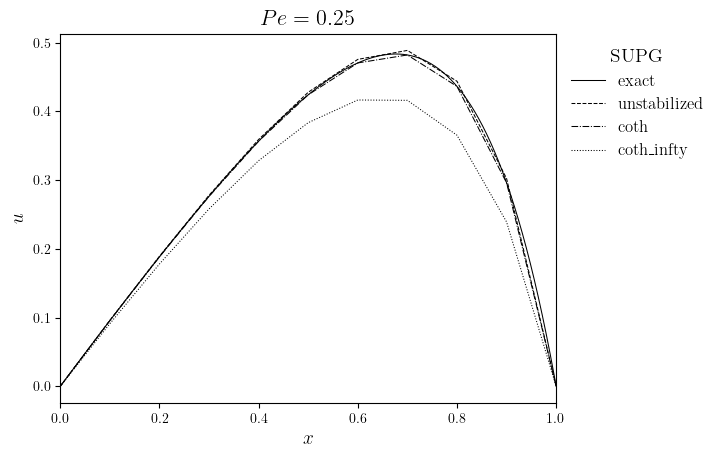

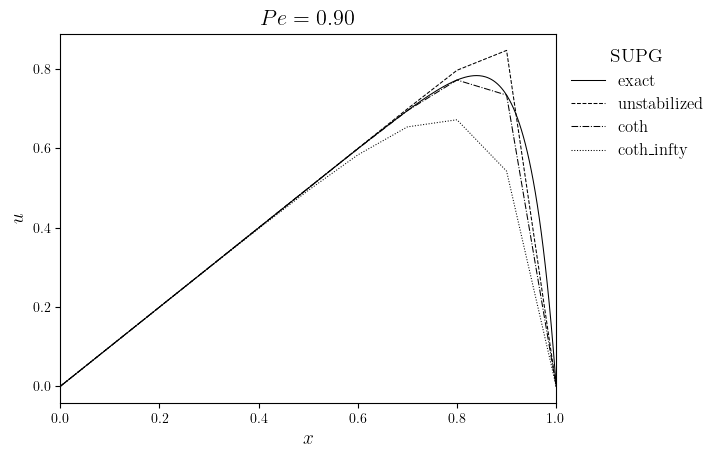

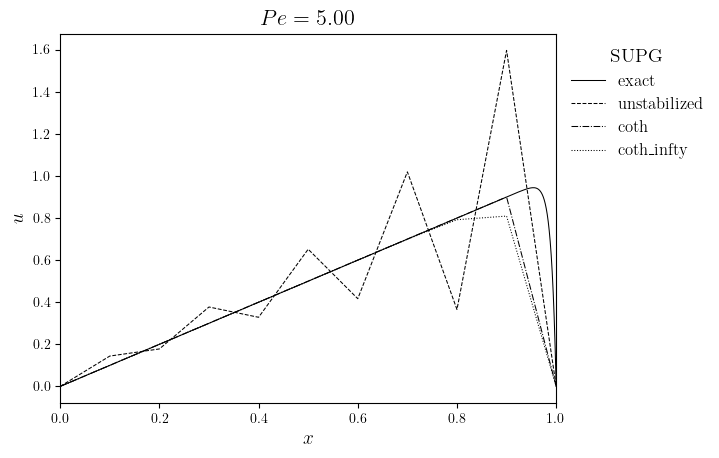

In [ ]:
def exact_solution(
    x: np.ndarray, 
    a: float, 
    d: float,
) -> np.ndarray:    
    return (1 / a) * (x - (1 - np.exp(a * x / d)) / (1.0 - np.exp(a / d)))

x = np.linspace(0, Lx, num=500)

for d in d_opts:
    lines = [(x, exact_solution(x, a, d))]
    legend_labels = ['exact']
    for tau in tau_opts:
        lines.append(solutions[d][tau])
        if tau is None:
            tau = 'unstabilized'
        legend_labels.append(tau)
    Pe = peclet(h, a, d)
    fig, ax = plot_line(lines, legend_labels, 'SUPG', x_lims=x, x_label='$x$', y_label='$u$', title=f'$Pe={Pe:.2f}$')
    save_figure(f'Pe={Pe:.2f}', thumbnail=(d == d_opts[-1]))(fig)